In [1]:
import sys
import pandas as pd
from pathlib import Path
import os

# Add src/ to path so settings.py can be found
sys.path.insert(0, str(Path().resolve()))
from settings import config
BASE_DIR = Path(os.getcwd()).parent
DATA_DIR = BASE_DIR / "_data"

df_spx   = pd.read_parquet(DATA_DIR / "crsp_sp500_daily.parquet")
df_opt   = pd.read_parquet(DATA_DIR / "optionmetrics_spx_monthly.parquet")
df_zero  = pd.read_parquet(DATA_DIR / "optionmetrics_zero_curve.parquet")
df_ff    = pd.read_parquet(DATA_DIR / "fama_french_monthly.parquet")
df_treas = pd.read_parquet(DATA_DIR / "crsp_treasury_returns.parquet")

print("SPX:    ", df_spx.columns.tolist())
print("Options:", df_opt.columns.tolist())
print("Zero:   ", df_zero.columns.tolist())
print("FF:     ", df_ff.columns.tolist())
print("Treas:  ", df_treas.columns.tolist())

SPX:     ['date', 'spindx', 'sprtrn', 'vwretd', 'vwretx']
Options: ['date', 'exdate', 'cp_flag', 'strike', 'best_bid', 'best_offer', 'impl_volatility', 'delta', 'gamma', 'vega', 'volume', 'open_interest', 'mid_price', 'days_to_maturity', 'year']
Zero:    ['date', 'days', 'rate']
FF:      ['date', 'mkt_rf_monthly', 'smb_monthly', 'hml_monthly', 'rf_1m_monthly']
Treas:   ['date', 'treasury_2y_ret', 'treasury_10y_ret']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Summary Statistics Table ─────────────────────────────────────────────────

def summarize(df, col, label):
    s = df[col].dropna()
    return {
        'Series': label,
        'N': len(s),
        'Mean': s.mean(),
        'Std': s.std(),
        'Min': s.min(),
        'Median': s.median(),
        'Max': s.max(),
        'Start': df['date'].min().strftime('%Y-%m'),
        'End': df['date'].max().strftime('%Y-%m'),
    }

rows = [
    summarize(df_spx,   'spindx',          'SPX index level'),
    summarize(df_spx,   'vwretd',          'Market return (daily, incl. div.)'),
    summarize(df_opt,   'mid_price',        'SPX option mid price ($)'),
    summarize(df_opt,   'days_to_maturity', 'Days to maturity'),
    summarize(df_opt,   'impl_volatility',  'Implied volatility'),
    summarize(df_zero,  'rate',             'Zero curve rate (%)'),
    summarize(df_ff,    'rf_1m_monthly',    '1-month T-bill rate (monthly)'),
    summarize(df_treas, 'treasury_2y_ret',  '2Y Treasury return (monthly)'),
    summarize(df_treas, 'treasury_10y_ret', '10Y Treasury return (monthly)'),
]

df_summary = pd.DataFrame(rows).set_index('Series')
df_summary[['Mean','Std','Min','Median','Max']] = \
    df_summary[['Mean','Std','Min','Median','Max']].round(4)

print("Data Summary Statistics")
display(df_summary)

Data Summary Statistics


,N,Mean,Std,Min,Median,Max,Start,End
Series,,,,,,,,
SPX index level,7300,1956.4082,1221.1228,598.4800,1394.4950,6090.2700,1996-01,2024-12
"Market return (daily, incl. div.)",7300,0.0004,0.0119,-0.1182,0.0008,0.1149,1996-01,2024-12
SPX option mid price ($),760830,517.6762,736.2023,3.0000,222.8500,6726.8000,1996-01,2025-08
Days to maturity,760830,290.1678,274.8096,90.0000,183.0000,2184.0000,1996-01,2025-08
Implied volatility,723698,0.2404,0.1079,0.0365,0.2217,3.2986,1996-01,2025-08
Zero curve rate (%),304301,3.2876,2.1029,0.0587,2.9240,7.9819,1996-01,2025-08
1-month T-bill rate (monthly),360,0.0019,0.0018,0.0000,0.0014,0.0056,1996-01,2025-12
2Y Treasury return (monthly),348,0.0025,0.0051,-0.0151,0.0018,0.0207,1996-01,2024-12
10Y Treasury return (monthly),348,0.0033,0.0207,-0.0668,0.0025,0.0854,1996-01,2024-12


In [3]:
# ── Export to LaTeX ───────────────────────────────────────────────────────────

OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

latex = df_summary.to_latex(
    escape=True,
    na_rep="",
)

with open(OUTPUT_DIR / "data_summary.tex", "w") as f:
    f.write(latex)

print("Saved to output/data_summary.tex")

Saved to output/data_summary.tex


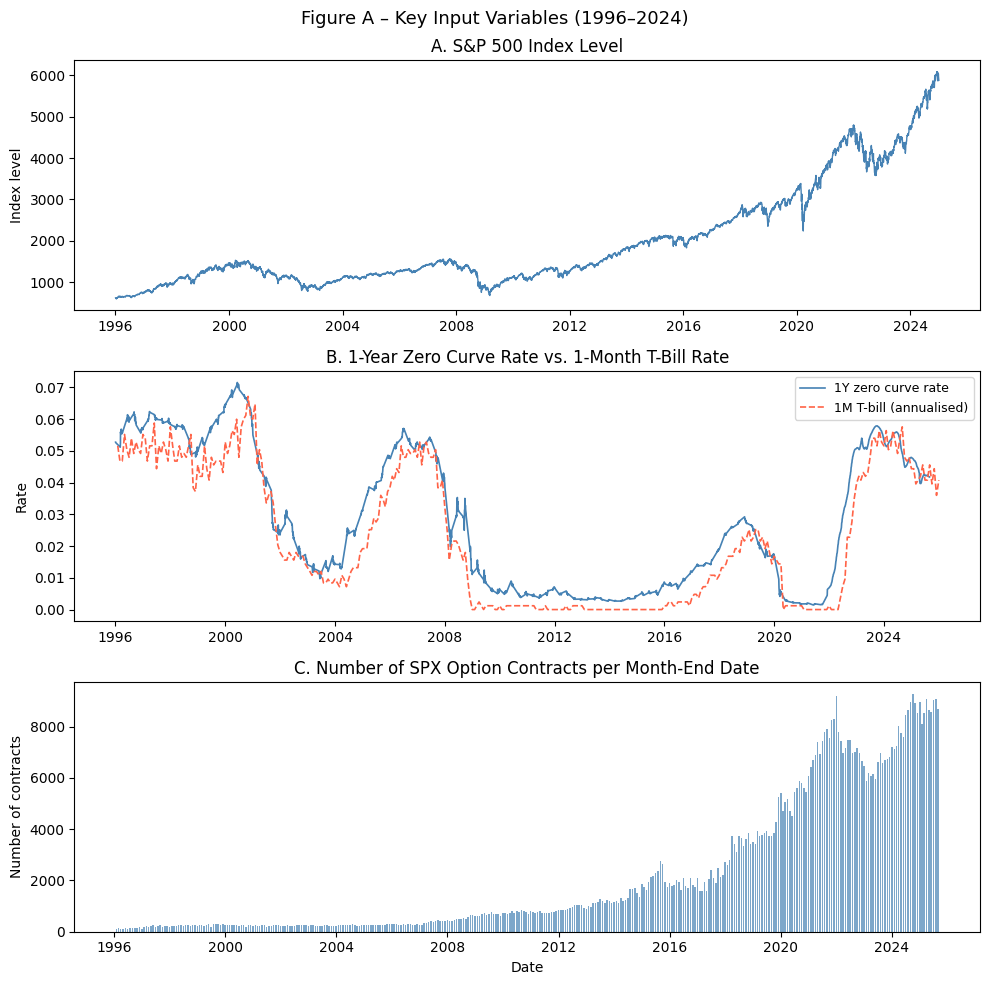

Saved figure_A_input_series


In [4]:
# ── Figure A: Time Series of Key Input Variables ──────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fig.suptitle("Figure A – Key Input Variables (1996–2024)", fontsize=13)

# Panel A: SPX index level
spx_daily = df_spx.copy()
axes[0].plot(spx_daily['date'], spx_daily['spindx'], lw=1, color='steelblue')
axes[0].set_title("A. S&P 500 Index Level")
axes[0].set_ylabel("Index level")
axes[0].set_xlabel("")

# Panel B: zero curve rate vs T-bill
zero_1y = df_zero[df_zero['days'].between(350, 380)].copy()
zero_1y = zero_1y.groupby('date')['rate'].mean().reset_index()
zero_1y['rate'] = zero_1y['rate'] / 100

ff_monthly = df_ff.copy()

axes[1].plot(zero_1y['date'],    zero_1y['rate'],        lw=1.2,
             label='1Y zero curve rate', color='steelblue')
axes[1].plot(ff_monthly['date'], ff_monthly['rf_1m_monthly'] * 12,
             lw=1.2, linestyle='--', label='1M T-bill (annualised)', color='tomato')
axes[1].set_title("B. 1-Year Zero Curve Rate vs. 1-Month T-Bill Rate")
axes[1].set_ylabel("Rate")
axes[1].legend(fontsize=9)

# Panel C: number of options contracts per month
opt_count = df_opt.groupby('date').size().reset_index(name='n_contracts')
axes[2].bar(opt_count['date'], opt_count['n_contracts'],
            width=20, color='steelblue', alpha=0.7)
axes[2].set_title("C. Number of SPX Option Contracts per Month-End Date")
axes[2].set_ylabel("Number of contracts")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_A_input_series.pdf", bbox_inches='tight')
plt.savefig(OUTPUT_DIR / "figure_A_input_series.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure_A_input_series")

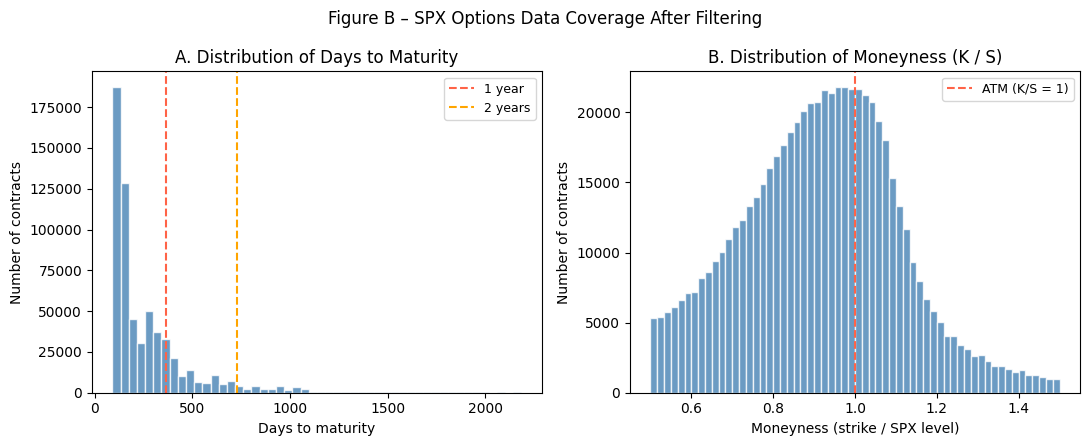

Saved figure_B_options_coverage


In [5]:
# ── Figure B: Options Data Coverage ──────────────────────────────────────────

# Apply paper filters
df_opt_clean = df_opt[
    (df_opt['mid_price'] >= 3) &
    (df_opt['days_to_maturity'] >= 90)
].copy()

# Merge spindx for moneyness
spx_monthly = df_spx.copy()
spx_monthly['year_month'] = spx_monthly['date'].dt.to_period('M')
spx_eom = spx_monthly.groupby('year_month')['spindx'].last().reset_index()
spx_eom['date'] = spx_eom['year_month'].dt.to_timestamp('M')

df_opt_clean['year_month'] = df_opt_clean['date'].dt.to_period('M')
df_opt_clean = df_opt_clean.merge(
    spx_eom[['year_month', 'spindx']], on='year_month', how='left'
)
df_opt_clean['moneyness'] = df_opt_clean['strike'] / df_opt_clean['spindx']
df_opt_clean = df_opt_clean[
    df_opt_clean['moneyness'].between(0.5, 1.5)
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Figure B – SPX Options Data Coverage After Filtering", fontsize=12)

# Panel A: days to maturity distribution
axes[0].hist(df_opt_clean['days_to_maturity'], bins=50,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(365, color='tomato', lw=1.5, linestyle='--', label='1 year')
axes[0].axvline(730, color='orange', lw=1.5, linestyle='--', label='2 years')
axes[0].set_title("A. Distribution of Days to Maturity")
axes[0].set_xlabel("Days to maturity")
axes[0].set_ylabel("Number of contracts")
axes[0].legend(fontsize=9)

# Panel B: moneyness distribution
axes[1].hist(df_opt_clean['moneyness'], bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(1.0, color='tomato', lw=1.5, linestyle='--', label='ATM (K/S = 1)')
axes[1].set_title("B. Distribution of Moneyness (K / S)")
axes[1].set_xlabel("Moneyness (strike / SPX level)")
axes[1].set_ylabel("Number of contracts")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_B_options_coverage.pdf", bbox_inches='tight')
plt.savefig(OUTPUT_DIR / "figure_B_options_coverage.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure_B_options_coverage")